# Atelier TensorFlow – Prédiction de la consommation énergétique d'un bâtiment

**Objectif :** construire avec TensorFlow/Keras un réseau de neurones capable de prédire la
consommation énergétique d'un bâtiment à partir de caractéristiques telles que la température,
l'humidité et le nombre d'occupants.

**Sommaire :**

0. Mise en place de l'environnement
1. Génération du dataset
2. Découpage Train/Test
3. Création du modèle
4. Compilation du modèle
5. Entraînement du modèle
6. Évaluation
7. Prédiction
8. Sauvegarde du modèle
9. Chargement du modèle
10. Fonction d'inférence
11. Bonus

## Partie 0 – Mise en place de l'environnement

Import des bibliothèques nécessaires et fixation des graines aléatoires pour garantir la
**reproductibilité** des résultats.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("NumPy :", np.__version__)
print("Matplotlib :", matplotlib.__version__)
print("TensorFlow :", tf.__version__)

NumPy : 2.5.1
Matplotlib : 3.11.1
TensorFlow : 2.21.0


## Partie 1 – Génération du dataset

On simule **1000 observations** issues de capteurs installés dans plusieurs bâtiments :

- `temperature` : loi normale (moyenne 25 °C, écart-type 4 °C) ;
- `humidite` : loi uniforme entre 30 % et 80 % ;
- `occupants` : entiers entre 1 et 49 inclus.

In [2]:
n_observations = 1000

temperature = np.random.normal(loc=25.0, scale=4.0, size=n_observations)
humidite = np.random.uniform(low=30.0, high=80.0, size=n_observations)
occupants = np.random.randint(low=1, high=50, size=n_observations)

print("temperature :", round(temperature.min(), 1), "->", round(temperature.max(), 1))
print("humidite    :", round(humidite.min(), 1), "->", round(humidite.max(), 1))
print("occupants   :", occupants.min(), "->", occupants.max())

temperature : 12.0 -> 40.4
humidite    : 30.2 -> 80.0
occupants   : 1 -> 49


La consommation est construite à partir d'une formule « physique » à laquelle on ajoute un
**bruit gaussien** (moyenne 0, écart-type 10) pour simuler les imprévus et les facteurs non mesurés :

`consommation = 50 + 5 × température + 1,5 × humidité + 4 × occupants + ε`  avec  `ε ~ N(0, 10²)`

In [3]:
bruit = np.random.normal(loc=0.0, scale=10.0, size=n_observations)

consommation = (
    50.0
    + 5.0 * temperature
    + 1.5 * humidite
    + 4.0 * occupants
    + bruit
)

Les variables explicatives sont rassemblées dans la matrice des caractéristiques **X**
(1000 × 3) et la cible dans le vecteur **y**, tous deux convertis au format `float32`,
optimisé pour les calculs TensorFlow.

In [4]:
X = np.column_stack((temperature, humidite, occupants)).astype("float32")
y = consommation.astype("float32")

print("X :", X.shape, X.dtype)
print("y :", y.shape, y.dtype)

X : (1000, 3) float32
y : (1000,) float32


## Partie 2 – Découpage Train/Test

On réserve **20 %** des données au test et les 80 % restants à l'entraînement.
Le découpage est rendu **reproductible** en mélangeant les indices avec une graine fixe.

In [5]:
np.random.seed(SEED)

n_test = int(0.2 * len(X))
indices = np.random.permutation(len(X))

indices_test = indices[:n_test]
indices_train = indices[n_test:]

X_train, X_test = X[indices_train], X[indices_test]
y_train, y_test = y[indices_train], y[indices_test]

print("Entraînement :", X_train.shape[0], "observations")
print("Test         :", X_test.shape[0], "observations")

Entraînement : 800 observations
Test         : 200 observations


## Partie 3 – Création du modèle

Architecture **séquentielle** :

- couche 1 : **16 neurones**, activation `relu` ;
- couche 2 : **8 neurones**, activation `relu` ;
- couche 3 : **1 seul neurone**, sans fonction d'activation : en régression la sortie doit pouvoir prendre n'importe quelle valeur réelle.

In [6]:
modele = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(3,), name="entrees"),
        tf.keras.layers.Dense(16, activation="relu", name="couche_cachee_1"),
        tf.keras.layers.Dense(8, activation="relu", name="couche_cachee_2"),
        tf.keras.layers.Dense(1, name="sortie"),
    ],
    name="modele_consommation",
)

In [7]:
modele.summary()

Model: "modele_consommation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ couche_cachee_1 (Dense)         │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_cachee_2 (Dense)         │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sortie (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

## Partie 4 – Compilation du modèle

Trois ingrédients sont nécessaires :

- **l'optimiseur** (`adam`) : la méthode qui ajuste les poids du réseau ;
- **la fonction de perte** (`mse`, erreur quadratique moyenne) : elle mesure l'erreur de prédiction que le modèle cherche à minimiser ;
- **la métrique** (`mae`, erreur absolue moyenne) : plus lisible, elle sert à suivre la qualité des prédictions.

In [8]:
modele.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"],
)

## Partie 5 – Entraînement du modèle

Hyper-paramètres utilisés :

- `validation_split=0.2` : 20 % des données d'entraînement servent à la validation à chaque fin d'époque ;
- `epochs=50` : 50 passages complets sur les données ;
- `batch_size=16` : 16 observations traitées à la fois.

L'historique renvoyé par `fit()` est conservé dans la variable **history**.

In [9]:
history = modele.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
)

Epoch 1/50


 1/40 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - loss: 119607.6094 - mae: 340.8231

23/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 115720.7812 - mae: 335.4133

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 114774.1016 - mae: 333.9269 - val_loss: 106780.0859 - val_mae: 322.6534


Epoch 2/50


...

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 135.9826 - mae: 9.2957 - val_loss: 124.3089 - val_mae: 8.9341


Epoch 50/50


 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 90.9230 - mae: 7.3665

25/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 132.2649 - mae: 9.2067

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 135.8719 - mae: 9.2941 - val_loss: 124.3747 - val_mae: 8.9368


### Examen du contenu de history

`history.history` est un dictionnaire : une liste de valeurs par métrique, avec une valeur par époque.

In [10]:
print(type(history).__name__)
print("Métriques enregistrées :", list(history.history.keys()))
print("Nombre d'époques :", len(history.history["loss"]))
print("Loss finale (entraînement) :", round(history.history["loss"][-1], 2))
print("Loss finale (validation)   :", round(history.history["val_loss"][-1], 2))

History
Métriques enregistrées : ['loss', 'mae', 'val_loss', 'val_mae']
Nombre d'époques : 50
Loss finale (entraînement) : 135.87
Loss finale (validation)   : 124.37


### Visualisation de l'apprentissage

On trace la perte (MSE) et la MAE à chaque époque, pour l'entraînement et pour la validation.

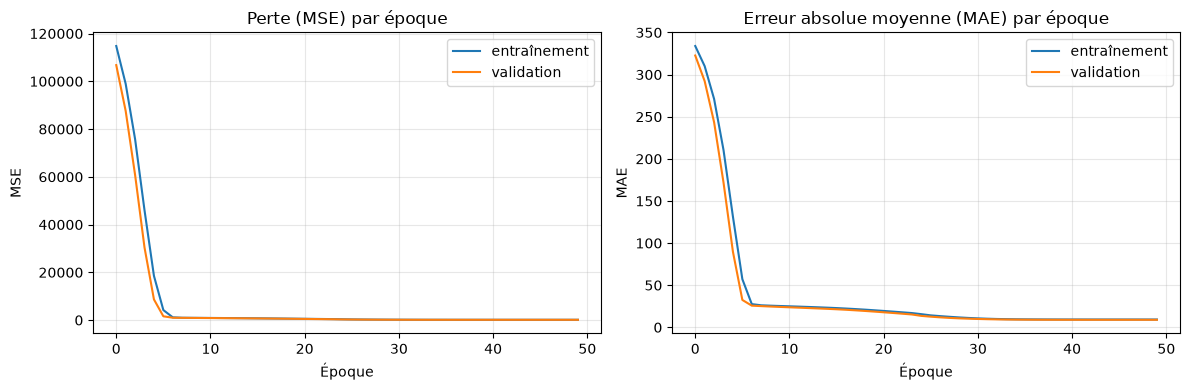

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="entraînement")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_title("Perte (MSE) par époque")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["mae"], label="entraînement")
axes[1].plot(history.history["val_mae"], label="validation")
axes[1].set_title("Erreur absolue moyenne (MAE) par époque")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Interprétation :** la perte chute très rapidement pendant les premières époques : le réseau
apprend l'essentiel de la relation dès les premiers passages sur les données. L'amélioration se
poursuit ensuite plus lentement jusqu'à l'époque 50. Les courbes de validation suivent de près
celles de l'entraînement (elles sont même légèrement meilleures) : il n'y a **pas de
sur-apprentissage**. La MAE finale (≈ 9 unités) approche l'écart-type du bruit injecté dans les
données (σ = 10) : le modèle se rapproche du plancher d'erreur irréductible, en dessous duquel
aucun modèle ne peut descendre sur ces données.

## Partie 6 – Évaluation sur les données de test

Le modèle est évalué sur des données qu'il n'a jamais vues pendant l'entraînement :
on récupère la **fonction de perte (MSE)** et la **métrique cible (MAE)**.

In [12]:
perte_test, mae_test = modele.evaluate(X_test, y_test, verbose=0)

print("Perte (MSE) sur le test :", round(float(perte_test), 2))
print("MAE sur le test         :", round(float(mae_test), 2))

Perte (MSE) sur le test : 161.22
MAE sur le test         : 10.16


**Interprétation :** la MSE sur le test reste du même ordre de grandeur que la variance du
bruit ajouté aux données (σ = 10 → σ² = 100). L'excès constaté s'explique par deux facteurs :
l'apprentissage, encore légèrement inachevé après 50 époques (la perte continuait de baisser
lentement), et la variabilité d'échantillonnage de l'ensemble de test, limité à 200 observations.
La MAE est plus parlante : en moyenne, la prédiction s'écarte d'une dizaine d'unités de la valeur
réelle, soit environ 3 % de la consommation typique (≈ 360 unités). Le modèle généralise bien :
aucune erreur systématique n'apparaît sur des données qu'il n'a jamais vues.

## Partie 7 – Prédiction

On prédit la consommation sur l'ensemble de test, puis on compare les prédictions aux valeurs réelles.

In [13]:
y_pred = modele.predict(X_test, verbose=0).ravel()

print(f"{'Réel':>8} | {'Prédit':>8} | {'Écart':>8}")
print("-" * 32)
for reel, predit in zip(y_test[:10], y_pred[:10]):
    print(f"{reel:8.1f} | {predit:8.1f} | {reel - predit:8.1f}")

    Réel |   Prédit |    Écart
--------------------------------
   334.9 |    337.3 |     -2.5
   383.1 |    393.8 |    -10.6
   377.8 |    365.2 |     12.7
   292.9 |    286.4 |      6.4
   396.4 |    395.8 |      0.6
   367.0 |    369.1 |     -2.0
   309.9 |    310.7 |     -0.8
   293.6 |    285.6 |      8.0
   360.9 |    368.7 |     -7.9
   414.3 |    414.9 |     -0.6


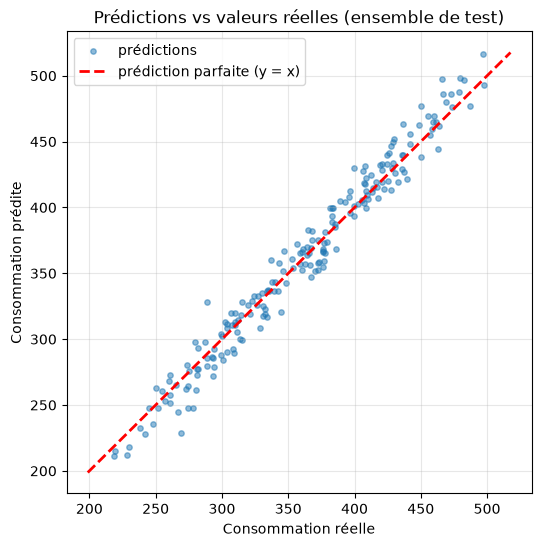

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=15, label="prédictions")
limite = [float(y_test.min()) - 20, float(y_test.max()) + 20]
plt.plot(limite, limite, "r--", linewidth=2, label="prédiction parfaite (y = x)")
plt.xlabel("Consommation réelle")
plt.ylabel("Consommation prédite")
plt.title("Prédictions vs valeurs réelles (ensemble de test)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interprétation :** les écarts entre valeurs réelles et prédites sont petits (quelques unités)
et le nuage de points est **aligné le long de la diagonale**.

Si le modèle était **parfait**, tous les points seraient exactement posés sur la diagonale rouge
`y = x` : chaque prédiction vaudrait exactement la valeur réelle. Ici, les points s'en écartent
légèrement, d'un ordre de grandeur égal au bruit contenu dans les données elles-mêmes.

## Partie 8 – Sauvegarde du modèle

Le modèle est sauvegardé au format natif de Keras (`.keras`) dans le dossier `models/` du projet.

In [15]:
import os

os.makedirs("../models", exist_ok=True)
modele.save("../models/modele_consommation.keras")

print("Modèle sauvegardé :", os.path.abspath("../models/modele_consommation.keras"))

Modèle sauvegardé : C:\Users\User\Documents\shered_directory\atelier TensorFlow\atelier_tensorflow_iot\models\modele_consommation.keras


## Partie 9 – Chargement du modèle

On recharge le modèle depuis le disque, comme on le ferait dans une application réelle,
sans avoir à redéfinir ni réentraîner quoi que ce soit.

In [16]:
modele_charge = tf.keras.models.load_model("../models/modele_consommation.keras")

In [17]:
modele_charge.summary()

Model: "modele_consommation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ couche_cachee_1 (Dense)         │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_cachee_2 (Dense)         │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sortie (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629 (2.46 KB)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 420 (1.64 KB)

In [18]:
nouvelle_observation = np.array([[22.5, 55.0, 10]], dtype="float32")
prediction_nouvelle = modele_charge.predict(nouvelle_observation, verbose=0)

print("Entrées (température, humidité, occupants) :", nouvelle_observation[0])
print("Consommation prédite :", round(float(prediction_nouvelle.ravel()[0]), 2))

Entrées (température, humidité, occupants) : [22.5 55.  10. ]
Consommation prédite : 281.39


## Partie 10 – Fonction d'inférence

On encapsule le modèle chargé dans une fonction prête à l'emploi : elle reçoit des valeurs
métier (température, humidité, occupants) et retourne directement la consommation prédite.

In [19]:
def predire_consommation(temperature, humidite, occupants):
    entrees = np.array([[temperature, humidite, occupants]], dtype="float32")
    prediction = modele_charge.predict(entrees, verbose=0)
    return float(prediction.ravel()[0])

In [20]:
exemple_1 = predire_consommation(temperature=18.0, humidite=40.0, occupants=2)
exemple_2 = predire_consommation(temperature=28.0, humidite=70.0, occupants=30)

print("18 °C / 40 % / 2 occupants   ->", round(exemple_1, 1))
print("28 °C / 70 % / 30 occupants  ->", round(exemple_2, 1))

18 °C / 40 % / 2 occupants   -> 195.5
28 °C / 70 % / 30 occupants  -> 422.4


**Test de cohérence :** la formule théorique donne respectivement
50 + 5×18 + 1,5×40 + 4×2 = **208** et 50 + 5×28 + 1,5×70 + 4×30 = **415**.
Les prédictions du modèle sont très proches de ces valeurs (aux fluctuations près liées au bruit),
ce qui valide toute la chaîne : sauvegarde → chargement → inférence.